In [3]:
import pandas            as pd
import xarray            as xr
import matplotlib.pyplot as plt

from pathlib            import Path
from datetime           import datetime
from matplotlib.patches import Rectangle

In [68]:
""" Patch Catalog """

catalog = pd.DataFrame({

    "spacecraft": [
        "Solar Orbiter",
        "Solar Orbiter",
        "Solar Orbiter",
        "Solar Orbiter",
        "Parker Solar Probe",
        "Parker Solar Probe"
    ],

    "interval": [
        "SolO 1",
        "SolO 2",
        "Solo 3",
        "SolO 4",
        "PSP 1",
        "PSP 2",
    ],

    "date_start": [
        datetime(2025, 3, 17),
        datetime(2022, 10, 21),
        datetime(2022, 9, 14),
        datetime(2023, 2, 22),
        datetime(2021, 11, 19),   
        datetime(2020, 6, 2),
    ],

    "date_end": [
        datetime(2025, 4, 13),
        datetime(2022, 10, 29),
        datetime(2022, 9, 18),
        datetime(2023, 2, 26),
        datetime(2021, 11, 22),
        datetime(2020, 6, 7),
    ],

    "r_min": [
        0.29,
        0.35,
        0.56,
        0.76,
        0.06,
        0.13,
    ],

    "r_max": [
        0.42,
        0.45,
        0.61,
        0.79,
        0.14,
        0.24,
    ],
})

spacecraft_names = {
    "Solar Orbiter": "SolO",
    "Parker Solar Probe": "PSP",
}

# --- Convert dates to datetime
catalog["date_start"] = pd.to_datetime(catalog["date_start"])
catalog["date_end"]   = pd.to_datetime(catalog["date_end"])


# --- Sort by spacecraft and minimum heliocentric distance
catalog = catalog.sort_values(
    by=["spacecraft", "r_min"],
    ascending=[True, True]
).reset_index(drop=True)


# --- Renumber intervals for each spacecraft
catalog["interval"] = (
    catalog.groupby("spacecraft")
           .cumcount()
           .add(1)
           .astype(str)
)

catalog["interval"] = (
    catalog["spacecraft"].map(spacecraft_names)
    + " "
    + catalog["interval"]
)


# --- Save catalog to NetCDF
ds = xr.Dataset.from_dataframe(catalog.set_index("interval"))

catalog_path = Path("patch_catalog.nc")

ds.to_netcdf(catalog_path)

print(catalog)

           spacecraft interval date_start   date_end  r_min  r_max
0  Parker Solar Probe    PSP 1 2021-11-19 2021-11-22   0.06   0.14
1  Parker Solar Probe    PSP 2 2020-06-02 2020-06-07   0.13   0.24
2       Solar Orbiter   SolO 1 2025-03-17 2025-04-13   0.29   0.42
3       Solar Orbiter   SolO 2 2022-10-21 2022-10-29   0.35   0.45
4       Solar Orbiter   SolO 3 2022-09-14 2022-09-18   0.56   0.61
5       Solar Orbiter   SolO 4 2023-02-22 2023-02-26   0.76   0.79


In [70]:
catalog_path = "patch_catalog.nc"

ds = xr.open_dataset(catalog_path)

print(ds)

<xarray.Dataset> Size: 768B
Dimensions:     (interval: 6)
Coordinates:
  * interval    (interval) <U6 144B 'PSP 1' 'PSP 2' ... 'SolO 3' 'SolO 4'
Data variables:
    spacecraft  (interval) <U18 432B ...
    date_start  (interval) datetime64[ns] 48B ...
    date_end    (interval) datetime64[ns] 48B ...
    r_min       (interval) float64 48B ...
    r_max       (interval) float64 48B ...


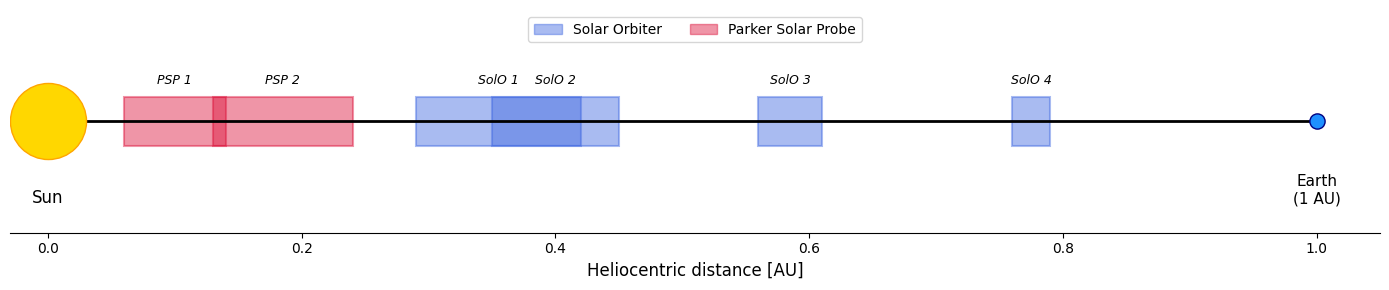

In [72]:
# --- Figure
fig, ax = plt.subplots(figsize=(14, 3))


# --- Main horizontal axis (Sun -> Earth)
ax.hlines(
    y=0,
    xmin=0,
    xmax=1.0,
    color="black",
    linewidth=2
)

# --- Catalog intervals
for interval in ds.interval.values:

    spacecraft = ds.spacecraft.sel(interval=interval).item()

    rmin = ds.r_min.sel(interval=interval).item()
    rmax = ds.r_max.sel(interval=interval).item()

    if spacecraft == "Solar Orbiter":

        color = "royalblue"

    elif spacecraft == "Parker Solar Probe":

        color = "crimson"

    else:

        raise ValueError(
            f"Unknown spacecraft: {spacecraft}"
        )


    # Interval
    rect = Rectangle(
        (rmin, -0.1),
        rmax - rmin,
        0.2,
        facecolor=color,
        edgecolor=color,
        alpha=0.45,
        linewidth=1.5
    )

    ax.add_patch(rect)


    # Label
    ax.text(
        (rmin + rmax) / 2,
        0.14,
        interval,
        ha="center",
        va="bottom",
        fontsize=9,
        fontstyle="italic",
        color="black"
    )

# --- Sun
ax.scatter(
    0,
    0,
    s=3000,
    color="gold",
    edgecolor="orange",
    zorder=10
)

ax.text(
    0,
    -0.33,
    "Sun",
    ha="center",
    fontsize=12
)

# --- Earth
ax.scatter(
    1.0,
    0,
    s=120,
    color="dodgerblue",
    edgecolor="navy",
    zorder=10
)

ax.text(
    1.0,
    -0.33,
    "Earth\n(1 AU)",
    ha="center",
    fontsize=11
)

# --- Formatting
ax.set_xlim(-0.03, 1.05)
ax.set_ylim(-0.45, 0.45)

ax.set_xlabel(
    "Heliocentric distance [AU]",
    fontsize=12
)

ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# --- Legend
handles = [
    Rectangle(
        (0, 0),
        1,
        1,
        color="royalblue",
        alpha=0.45
    ),

    Rectangle(
        (0, 0),
        1,
        1,
        color="crimson",
        alpha=0.45
    )
]

labels = [
    "Solar Orbiter",
    "Parker Solar Probe"
]

ax.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2
)


plt.tight_layout()

# plt.savefig("timeline.png",dpi=300,bbox_inches="tight",transparent=True)

plt.show()